# Segmentation de la Clientèle du Commerce de Détail

## Introduction
Ce projet consiste à explorer un ensemble de données sur le commerce de détail afin d'identifier les segments de clientèle en fonction des habitudes d'achat. Il s'agit d'une introduction idéale aux techniques d'apprentissage non supervisé.

## Objectifs
- Nettoyer et prétraiter l'ensemble des données.
- Effectuer une analyse exploratoire des données (AED).
- Utiliser le regroupement K-means pour créer des segments de clientèle.
- Visualiser les résultats.

## Compétences Développées
- Regroupement K-means
- Prétraitement des données
- Analyse exploratoire des données

## Ensemble de Données
- Ensemble de données sur la segmentation des clients des centres commerciaux.

## Étapes de Réalisation du Projet

### 1. Prétraitement des Données
Le fichier `preprocessing.py` contient la fonction `preprocess_data` :

```python
import pandas as pd
from sklearn.preprocessing import StandardScaler

def preprocess_data(file_path):
    # Charger les données
    df = pd.read_csv(file_path)

    # Vérifier les valeurs manquantes
    print(df.isnull().sum())

    # Encoder les variables catégorielles
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

    # Sélectionner les caractéristiques pertinentes
    X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

    # Standardiser les données
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, df
```
**Explication :**  
Cette fonction charge le fichier CSV contenant les données des clients, vérifie les valeurs manquantes, encode la variable de genre, sélectionne les caractéristiques pertinentes, et standardise les données.

### 2. Analyse Exploratoire des Données
Le fichier `exploration.py` permet de réaliser une analyse exploratoire :

```python
import seaborn as sns
import matplotlib.pyplot as plt

def explore_data(df):
    # Visualiser la distribution des données
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
    plt.title('Distribution des Clients par Revenu et Score de Dépense')
    plt.show()

    # Visualiser les corrélations
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, fmt=".2f")
    plt.title('Matrice de Corrélation')
    plt.show()
```
**Explication :**  
Cette fonction visualise la distribution des clients en fonction de leur revenu annuel et de leur score de dépense, tout en montrant les corrélations entre les différentes variables.

### 3. Regroupement K-means
Le fichier `clustering.py` contient la fonction `kmeans_clustering` :

```python
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def kmeans_clustering(X_scaled, df):
    # Déterminer le nombre optimal de clusters
    inertia = []
    K = range(1, 11)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(K, inertia, marker='o')
    plt.title('Méthode du Coude')
    plt.xlabel('Nombre de Clusters')
    plt.ylabel('Inertie')
    plt.show()

    # Appliquer K-means avec le nombre optimal de clusters
    optimal_k = 5  # Ajustez selon le graphique
    kmeans = KMeans(n_clusters=optimal_k, random_state=42)
    df['Cluster'] = kmeans.fit_predict(X_scaled)

    return df
```
**Explication :**  
Cette fonction utilise la méthode du coude pour déterminer le nombre optimal de clusters pour le regroupement K-means, puis applique K-means pour segmenter les clients.

### 4. Visualisation des Résultats
Le fichier `visualization.py` permet de visualiser les résultats des clusters :

```python
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_clusters(df):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
    plt.title('Segments de Clientèle')
    plt.show()
```
**Explication :**  
Cette fonction crée un graphique de dispersion pour visualiser les segments de clientèle identifiés par le regroupement K-means.

## Graphiques

### 1. Distribution des Clients par Revenu et Score de Dépense
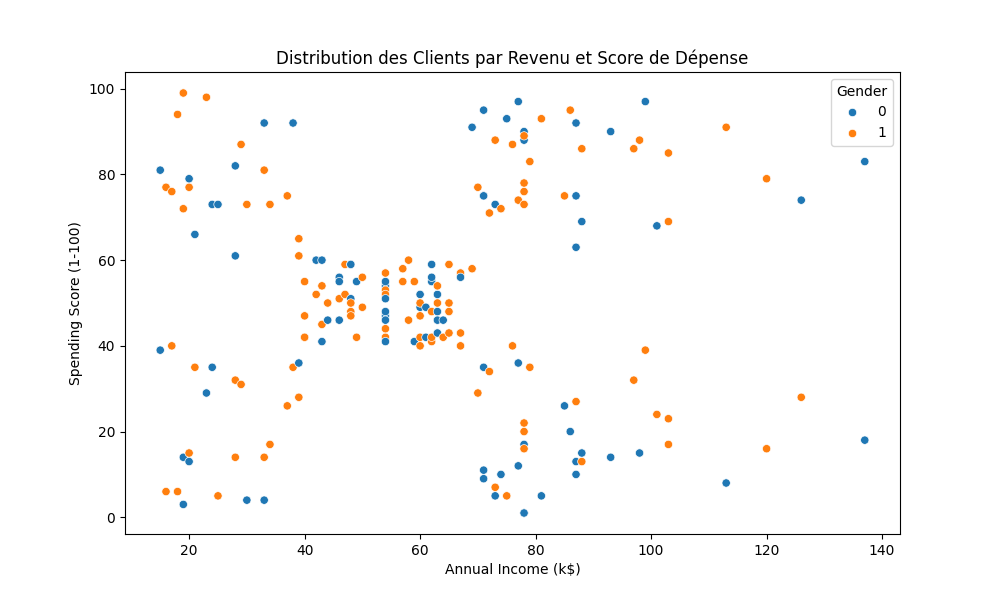
**Description du Graphique**  
Ce graphique de dispersion montre la distribution des clients en fonction de leur revenu annuel (en milliers de dollars) et de leur score de dépense (sur une échelle de 1 à 100). Les points sont colorés selon le genre : bleu pour les hommes (0) et orange pour les femmes (1).

**Interprétation**
- **Tendances Générales** : On peut observer que les clients avec un revenu plus élevé n'ont pas nécessairement un score de dépense proportionnellement plus élevé, ce qui indique des comportements d'achat variés.
- **Segmentation par Genre** : La répartition des points montre des différences potentielles dans les habitudes de dépense entre les hommes et les femmes, ce qui pourrait être utile pour des campagnes de marketing ciblées.
- **Rôle dans l'Analyse** : Ce graphique est généré par la fonction `explore_data` dans le module `exploration.py` et permet d'initier une compréhension visuelle des données clients, facilitant ainsi des analyses plus profondes.

### 2. Matrice de Corrélation
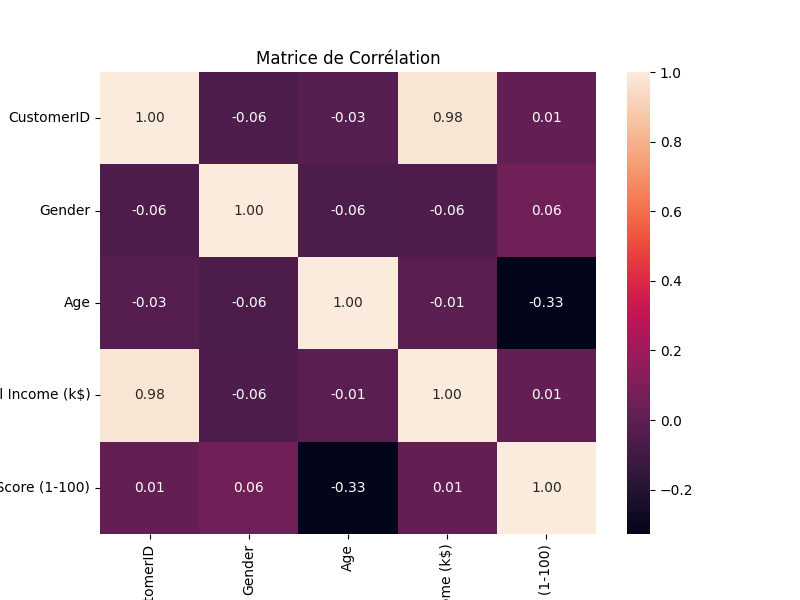
**Description du Graphique**  
Cette matrice de corrélation représente les relations entre toutes les variables du DataFrame. Les valeurs varient entre -1 et 1, où 1 indique une corrélation positive parfaite, -1 une corrélation négative parfaite, et 0 aucune corrélation.

**Interprétation**
- **Corrélations Notables** : On observe une forte corrélation positive entre le revenu annuel et le score de dépense (0.60), suggérant que les clients avec un revenu plus élevé tendent à avoir un score de dépense plus élevé.
- **Utilisation des Données** : Cette matrice permet d’identifier les relations entre les variables et peut aider à sélectionner les caractéristiques pertinentes pour le modèle de regroupement K-means.
- **Rôle dans l'Analyse** : Ce graphique est également généré par la fonction `explore_data` et est essentiel pour comprendre les interactions entre les différentes caractéristiques des clients.

### 3. Méthode du Coude
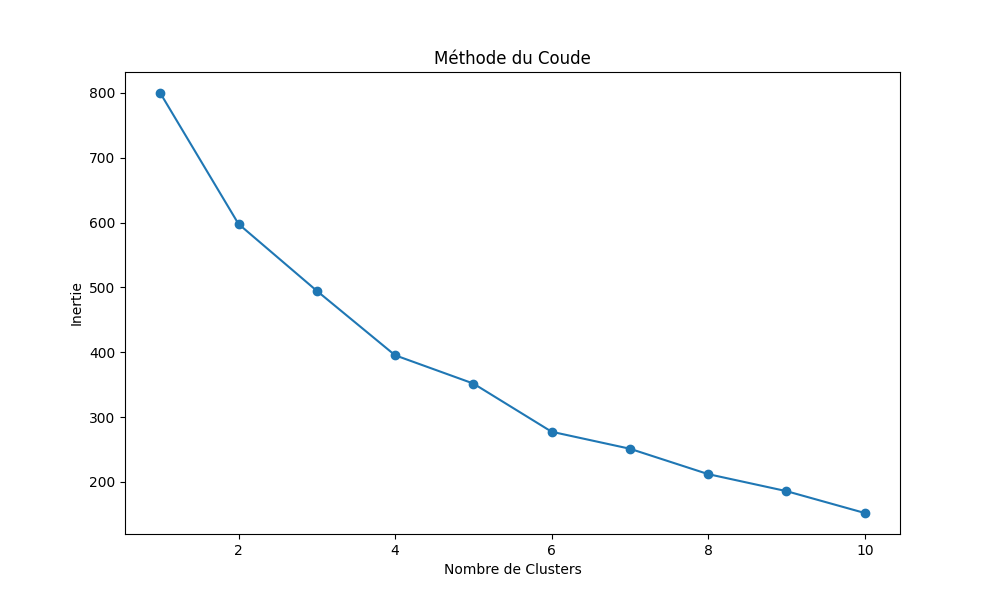
**Description du Graphique**  
Ce graphique montre l'inertie en fonction du nombre de clusters (K) utilisé dans l'algorithme K-means. L'inertie représente la somme des distances au carré entre chaque point et le centre de son cluster.

**Interprétation**
- **Détermination du Nombre Optimal de Clusters** : On peut observer que l'inertie diminue avec l'augmentation du nombre de clusters, mais il y a un "coude" visible vers K=5. Cela indique que l'ajout de plus de clusters au-delà de ce point n'apporte pas une réduction significative de l'inertie.
- **Utilisation dans le Modèle** : Ce graphique joue un rôle crucial dans la sélection du nombre optimal de clusters à utiliser dans l'algorithme K-means.
- **Rôle dans l'Analyse** : Ce graphique est généré par la fonction `kmeans_clustering` dans le module `clustering.py` et aide à justifier le choix du nombre de clusters pour l'analyse.

### 4. Segments de Clientèle
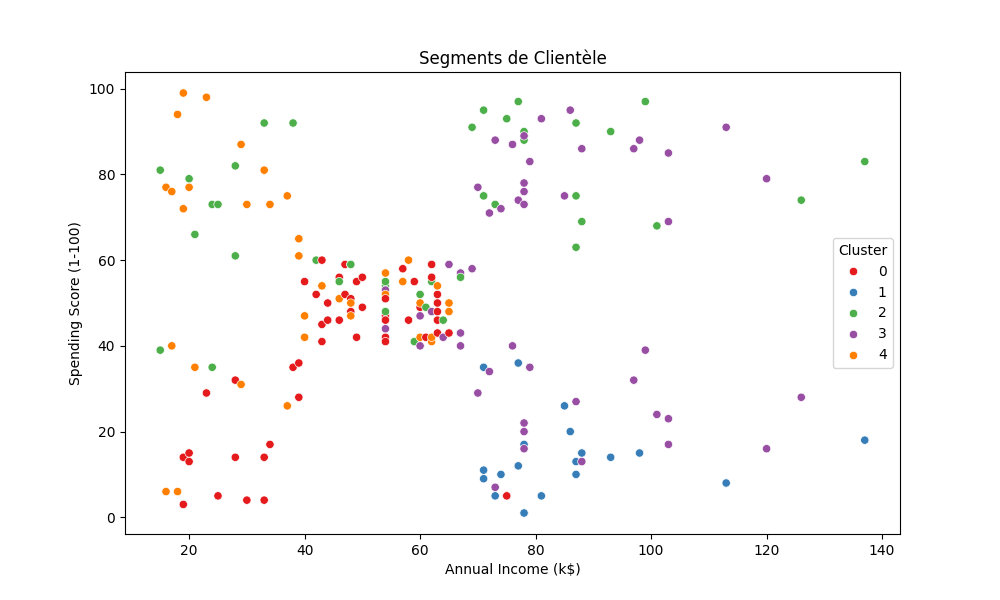
**Description du Graphique**  
Ce graphique de dispersion montre les segments de clientèle identifiés par l'algorithme K-means, avec chaque couleur représentant un cluster différent. Les axes sont les mêmes que ceux du premier graphique.

**Interprétation**
- **Identification des Segments** : Les différents clusters montrent comment les clients peuvent être regroupés en fonction de leurs comportements d'achat. Par exemple, un certain segment peut avoir un revenu élevé mais un score de dépense faible, et vice versa.
- **Visualisation des Résultats** : Ce graphique facilite l'identification visuelle des segments de clientèle, ce qui peut être très utile pour le marketing et la personnalisation de l'expérience client.
- **Rôle dans l'Analyse** : Ce graphique est généré par la fonction `visualize_clusters` dans le module `visualization.py`, et il est essentiel pour visualiser et interpréter les résultats du modèle de regroupement K-means.

## Conclusion
Ce projet a permis d'acquérir des compétences importantes en matière de traitement des données, d'analyse exploratoire et de techniques de regroupement. En utilisant le K-means, nous avons pu identifier des segments de clientèle basés sur les habitudes d'achat, ce qui peut aider les entreprises à mieux cibler leurs stratégies marketing et à améliorer leur service à la clientèle.